In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import *
rcParams['pdf.fonttype']=42 # in order to save fonttype in AI
rcParams['ps.fonttype']=42

In [2]:
monkey = sc.read('../data_h5/Insular_sorted_clusters.h5ad')

In [3]:
monkey.X = monkey.layers['counts'].copy()
sc.pp.normalize_total(monkey, target_sum=1e4)
sc.pp.log1p(monkey)

In [4]:
monkey.obs['label_main'] = monkey.obs['cellTypeLabel'].copy()

In [5]:
np.unique(monkey.obs['label_main'])

array(['Astrocyte', 'EnVL', 'Exc neuron', 'Inhib neuron', 'Meis2 neuron',
       'Microglia', 'OPC', 'Oligodendrocyte'], dtype=object)

In [6]:
np.unique(monkey.obs['cellTypeLabel'])

array(['Astrocyte', 'EnVL', 'Exc neuron', 'Inhib neuron', 'Meis2 neuron',
       'Microglia', 'OPC', 'Oligodendrocyte'], dtype=object)

/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


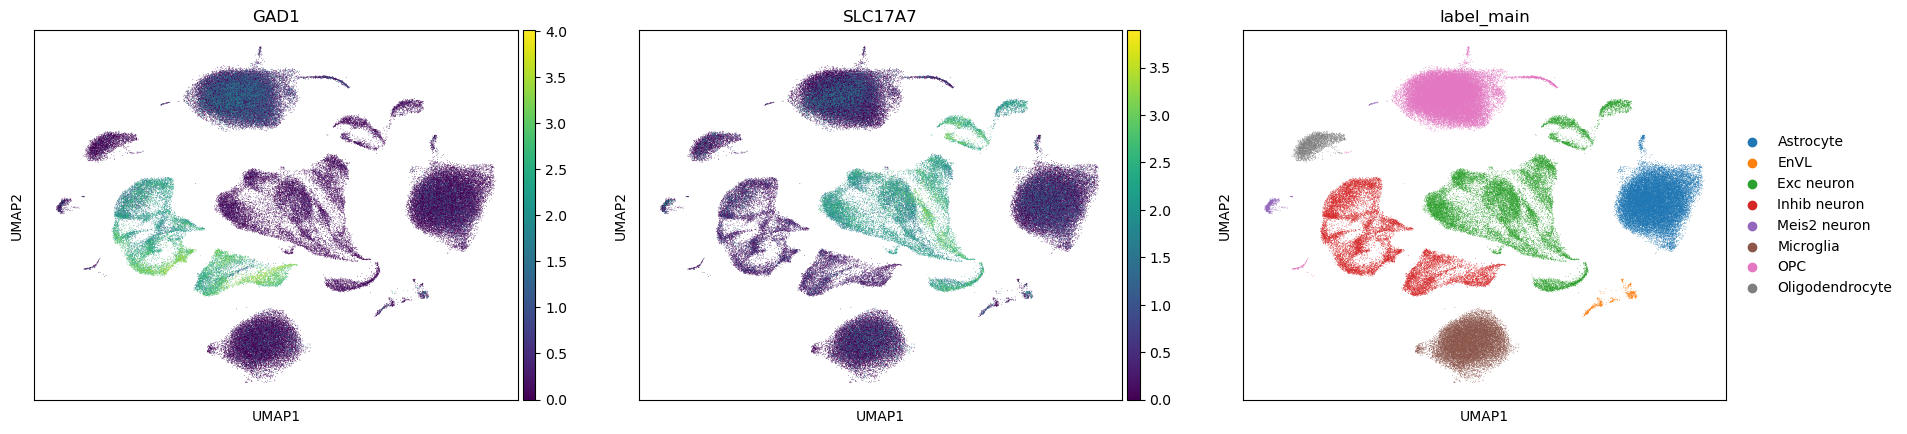

In [7]:
sc.pl.umap(monkey,color=['GAD1','SLC17A7','label_main'])

In [8]:
# import another dataset
ad_acc = sc.read('krameeva_acc_data/acc_label_main.h5ad')

In [9]:
human_acc = ad_acc[ad_acc.obs['orig.ident']=='H',]
monkey_acc = ad_acc[ad_acc.obs['orig.ident']=='M',]
Chimpanzee_acc = ad_acc[ad_acc.obs['orig.ident']=='C',]
Bonobo_acc = ad_acc[ad_acc.obs['orig.ident']=='B',]

In [10]:
rename_dict = dict()
rename_dict['Oligodendrocyte']='Oligo'
rename_dict['Oligodendrocyte precursor']='OPC'
rename_dict['Deep-layer corticothalamic and 6b']='EX'
rename_dict['Deep-layer intratelencephalic']='EX'
rename_dict['Deep-layer near-projecting']='EX'
rename_dict['MGE interneuron']='IN'
rename_dict['CGE interneuron']='IN'
rename_dict['Exc neuron']='EX'
rename_dict['Inhib neuron']='IN'
rename_dict['Oligodendrocyte precursor']='OPC'
rename_dict['Oligodendrocyte precursor']='OPC'
rename_dict['Astro']='Astrocyte'
rename_dict['Oligodendrocyte']='Oligo'
rename_dict['Oligodendrocyte']='Oligo'
rename_dict['Oligodendrocyte']='Oligo'
rename_dict['Oligodendrocyte']='Oligo'
rename_dict['Oligodendrocyte']='Oligo'
rename_dict['Oligodendrocyte']='Oligo'

In [11]:
human_acc.obs['org']='H_acc'
monkey_acc.obs['org'] = 'M_acc'
Chimpanzee_acc.obs['org']='C_acc'
Bonobo_acc.obs['org']='B_acc'
monkey.obs['org']='M_ins'

/tmp/ipykernel_2508/89918627.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  human_acc.obs['org']='H_acc'
/tmp/ipykernel_2508/89918627.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  monkey_acc.obs['org'] = 'M_acc'
/tmp/ipykernel_2508/89918627.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  Chimpanzee_acc.obs['org']='C_acc'
/tmp/ipykernel_2508/89918627.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  Bonobo_acc.obs['org']='B_acc'


In [13]:
common_gene = human_acc.var_names
for i in [human_acc,monkey_acc,Chimpanzee_acc,Bonobo_acc,monkey]:
    common_gene = common_gene[common_gene.isin(i.var_names)]

In [14]:
for i in [human_acc,monkey_acc,Chimpanzee_acc,Bonobo_acc,monkey]:
    i = i[:,common_gene]

In [15]:
ad = human_acc.concatenate([monkey_acc,Chimpanzee_acc,Bonobo_acc,monkey])

/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/anndata/_core/merge.py:942: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(
/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/anndata/_core/anndata.py:1785: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  [AnnData(sparse.csr_matrix(a.shape), obs=a.obs) for a in all_adatas],
/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/anndata/_core/anndata.py:1785: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  [AnnData(sparse.csr_matrix(a.shape), obs=a.obs) 

In [16]:
ad.obs['label_main'] = ad.obs['label_main'].map(lambda x:rename_dict.get(x,x))

In [17]:
n_hvg = 6000
sc.pp.highly_variable_genes(
    ad,n_top_genes=n_hvg,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5
)

In [18]:
sum(ad.var['highly_variable'])

6000

In [19]:
hvg = ad.var_names[ad.var['highly_variable']].tolist()

In [20]:
obs_dict=dict()
obs_dict['H_acc'] = human_acc
obs_dict['M_acc'] = monkey_acc
obs_dict['C_acc'] = Chimpanzee_acc
obs_dict['B_acc'] = Bonobo_acc
obs_dict['M_ins'] = monkey

In [21]:
human_acc = human_acc[:,hvg]
monkey_acc = monkey_acc[:,hvg]
Chimpanzee_acc = Chimpanzee_acc[:,hvg]
Bonobo_acc = Bonobo_acc[:,hvg]
monkey = monkey[:,hvg]

In [22]:
human_acc

View of AnnData object with n_obs × n_vars = 6780 × 6000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'louvain', 'label_main', 'org'
    var: 'name', 'ensmble'
    uns: 'label_main_colors', 'louvain', 'louvain_colors', 'neighbors', 'orig.ident_colors', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    obsp: 'connectivities', 'distances'

In [23]:
for i in obs_dict.values():
    i.obs['label_main'] = i.obs['label_main'].map(lambda x:rename_dict.get(x,x))
    sc.pp.scale(i,max_value=5)

In [24]:
human_acc

View of AnnData object with n_obs × n_vars = 6780 × 6000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'louvain', 'label_main', 'org'
    var: 'name', 'ensmble'
    uns: 'label_main_colors', 'louvain', 'louvain_colors', 'neighbors', 'orig.ident_colors', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    obsp: 'connectivities', 'distances'

In [25]:
obs_dict.get('M_ins').obs['label_main'].cat.categories

Index(['Astrocyte', 'EnVL', 'EX', 'IN', 'Meis2 neuron', 'Microglia', 'OPC',
       'Oligo'],
      dtype='object')

In [26]:
df = pd.DataFrame(index=hvg)

In [31]:
#for i in ['EX','IN','Astrocyte','Oligo','OPC','Microglia']:
for i in ['EX','IN','Astrocyte','Oligo','OPC','Microglia']:
    for j in ['M_ins','M_acc','H_acc','B_acc','C_acc']:
        if i in obs_dict.get(j).obs['label_main'].cat.categories:
            ad_temp = obs_dict.get(j)[:,common_gene]
            #sc.pp.scale(ad_temp,max_value=5)
            df_temp = ad_temp[ad_temp.obs['label_main']==i,].to_df().mean(0)
            df[j+'_'+i] = df_temp

In [32]:
df

,M_ins_EX,M_acc_EX,H_acc_EX,B_acc_EX,C_acc_EX,M_ins_IN,M_acc_IN,H_acc_IN,B_acc_IN,C_acc_IN,...,M_ins_OPC,M_acc_OPC,H_acc_OPC,B_acc_OPC,C_acc_OPC,M_ins_Microglia,M_acc_Microglia,H_acc_Microglia,B_acc_Microglia,C_acc_Microglia
C1orf112,-0.001646,-0.033061,-0.037071,-0.027859,-0.036306,-0.034774,-0.052135,-0.036550,-0.035229,-0.022387,...,-0.031935,-0.055803,-0.054892,-0.037518,-0.044319,-0.057229,-0.055803,-0.054892,-0.054949,-0.044319
GCLC,0.069220,-0.008301,-0.035336,0.048134,-0.045951,-0.027355,-0.045667,-0.050514,-0.080784,-0.030110,...,-0.142362,-0.157960,-0.013342,-0.081126,0.025062,-0.216539,-0.157960,-0.091866,-0.003284,-0.119139
STPG1,0.056163,-0.011850,-0.002391,0.004760,0.021853,-0.040218,-0.013259,-0.050824,-0.054850,-0.103282,...,-0.057526,-0.013259,-0.064031,-0.071337,-0.133039,-0.058543,-0.013259,-0.095194,-0.071338,-0.133039
NIPAL3,0.101274,0.101550,0.017087,0.121286,0.009032,0.022026,-0.113213,0.003445,-0.003978,0.056632,...,-0.018909,-0.380379,-0.049690,-0.223057,-0.127334,-0.141411,-0.129081,-0.145258,-0.241130,-0.100571
LAS1L,0.198517,0.042488,0.134821,0.108719,0.051773,0.074664,-0.074025,-0.016868,-0.044442,0.007449,...,-0.051746,-0.137943,-0.066905,-0.073142,-0.263020,-0.160428,-0.032954,-0.163165,-0.180321,-0.263020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GGNBP2,0.430515,0.046302,0.145153,0.270878,0.057262,0.361479,0.002175,-0.030172,0.002549,0.008454,...,-0.184285,-0.058442,-0.117328,-0.252513,-0.080630,-0.359992,-0.118645,0.004467,-0.084588,-0.085225
ZNF229,-0.033949,-0.026029,-0.045289,-0.034041,-0.038484,-0.049569,-0.028037,-0.029650,-0.040269,-0.047936,...,-0.019145,0.053594,-0.057175,-0.049153,-0.062610,-0.055166,-0.031688,-0.057175,-0.066624,-0.062610
DHRS11,0.240982,0.041575,0.045963,0.306966,0.077868,0.163667,-0.020251,-0.040721,-0.056045,-0.086461,...,-0.121803,-0.250753,-0.098261,-0.204865,-0.217677,-0.250844,0.044169,-0.114044,-0.222875,-0.120478
ACACA,0.252092,0.031612,0.053248,0.130858,0.052469,0.205935,-0.002037,-0.021959,-0.050815,-0.048704,...,-0.098673,-0.222353,-0.036366,-0.100518,-0.137165,-0.326708,-0.043201,-0.147141,-0.141959,-0.118227


In [33]:
ad.shape

(141282, 10168)

In [34]:
plot_data = df.corr()

<AxesSubplot: >

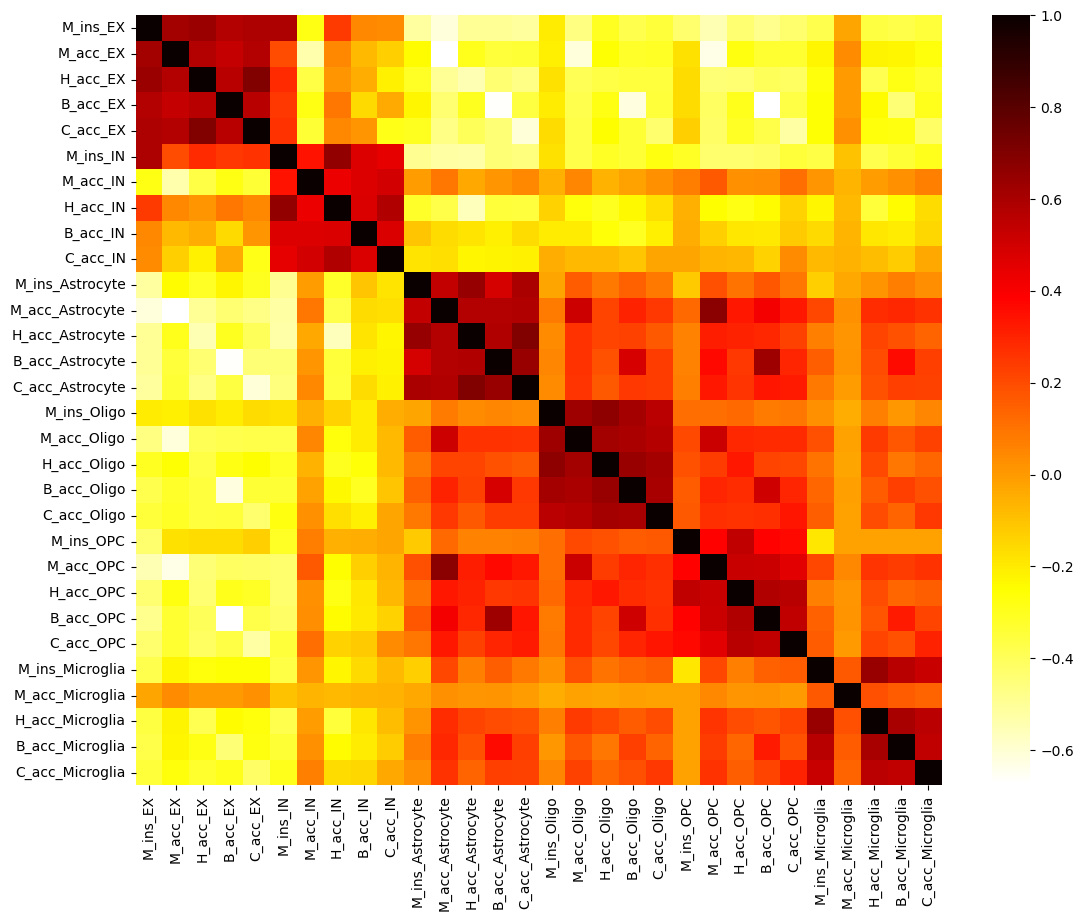

In [35]:
plt.figure(figsize=(13, 10)) 
sns.heatmap(plot_data,cmap='hot_r',)

In [36]:
plot_data.to_csv('cross_species_heatmap_matrix.csv')